These notebooks apply ArchVelo regression to human peripheral blood mononuclear cells (PBMC). The preprocessed data (from https://www.10xgenomics.com/datasets/pbmc-from-a-healthy-donor-granulocytes-removed-through-cell-sorting-10-k-1-standard-2-0-0) and other necessary files can be downloaded at https://doi.org/10.6084/m9.figshare.31909822

In [1]:
import scanpy as sc
import anndata
import numpy as np
import pandas as pd
import ArchVelo as av

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pickle

In [4]:
import os
fig_outdir = 'figures/'
os.makedirs(fig_outdir, exist_ok = True)

In [5]:
%matplotlib inline

# Regressions

## Results

In [6]:
f = open('test_k/rna_from_atac_pearson_corrs_CV.p', 'rb')
results_CV = pickle.load(f)
f.close()

In [7]:
f = open('test_raw/rna_from_atac_pearson_corrs_CV.p', 'rb')
results_raw = pickle.load(f)
f.close()

## Comparisons

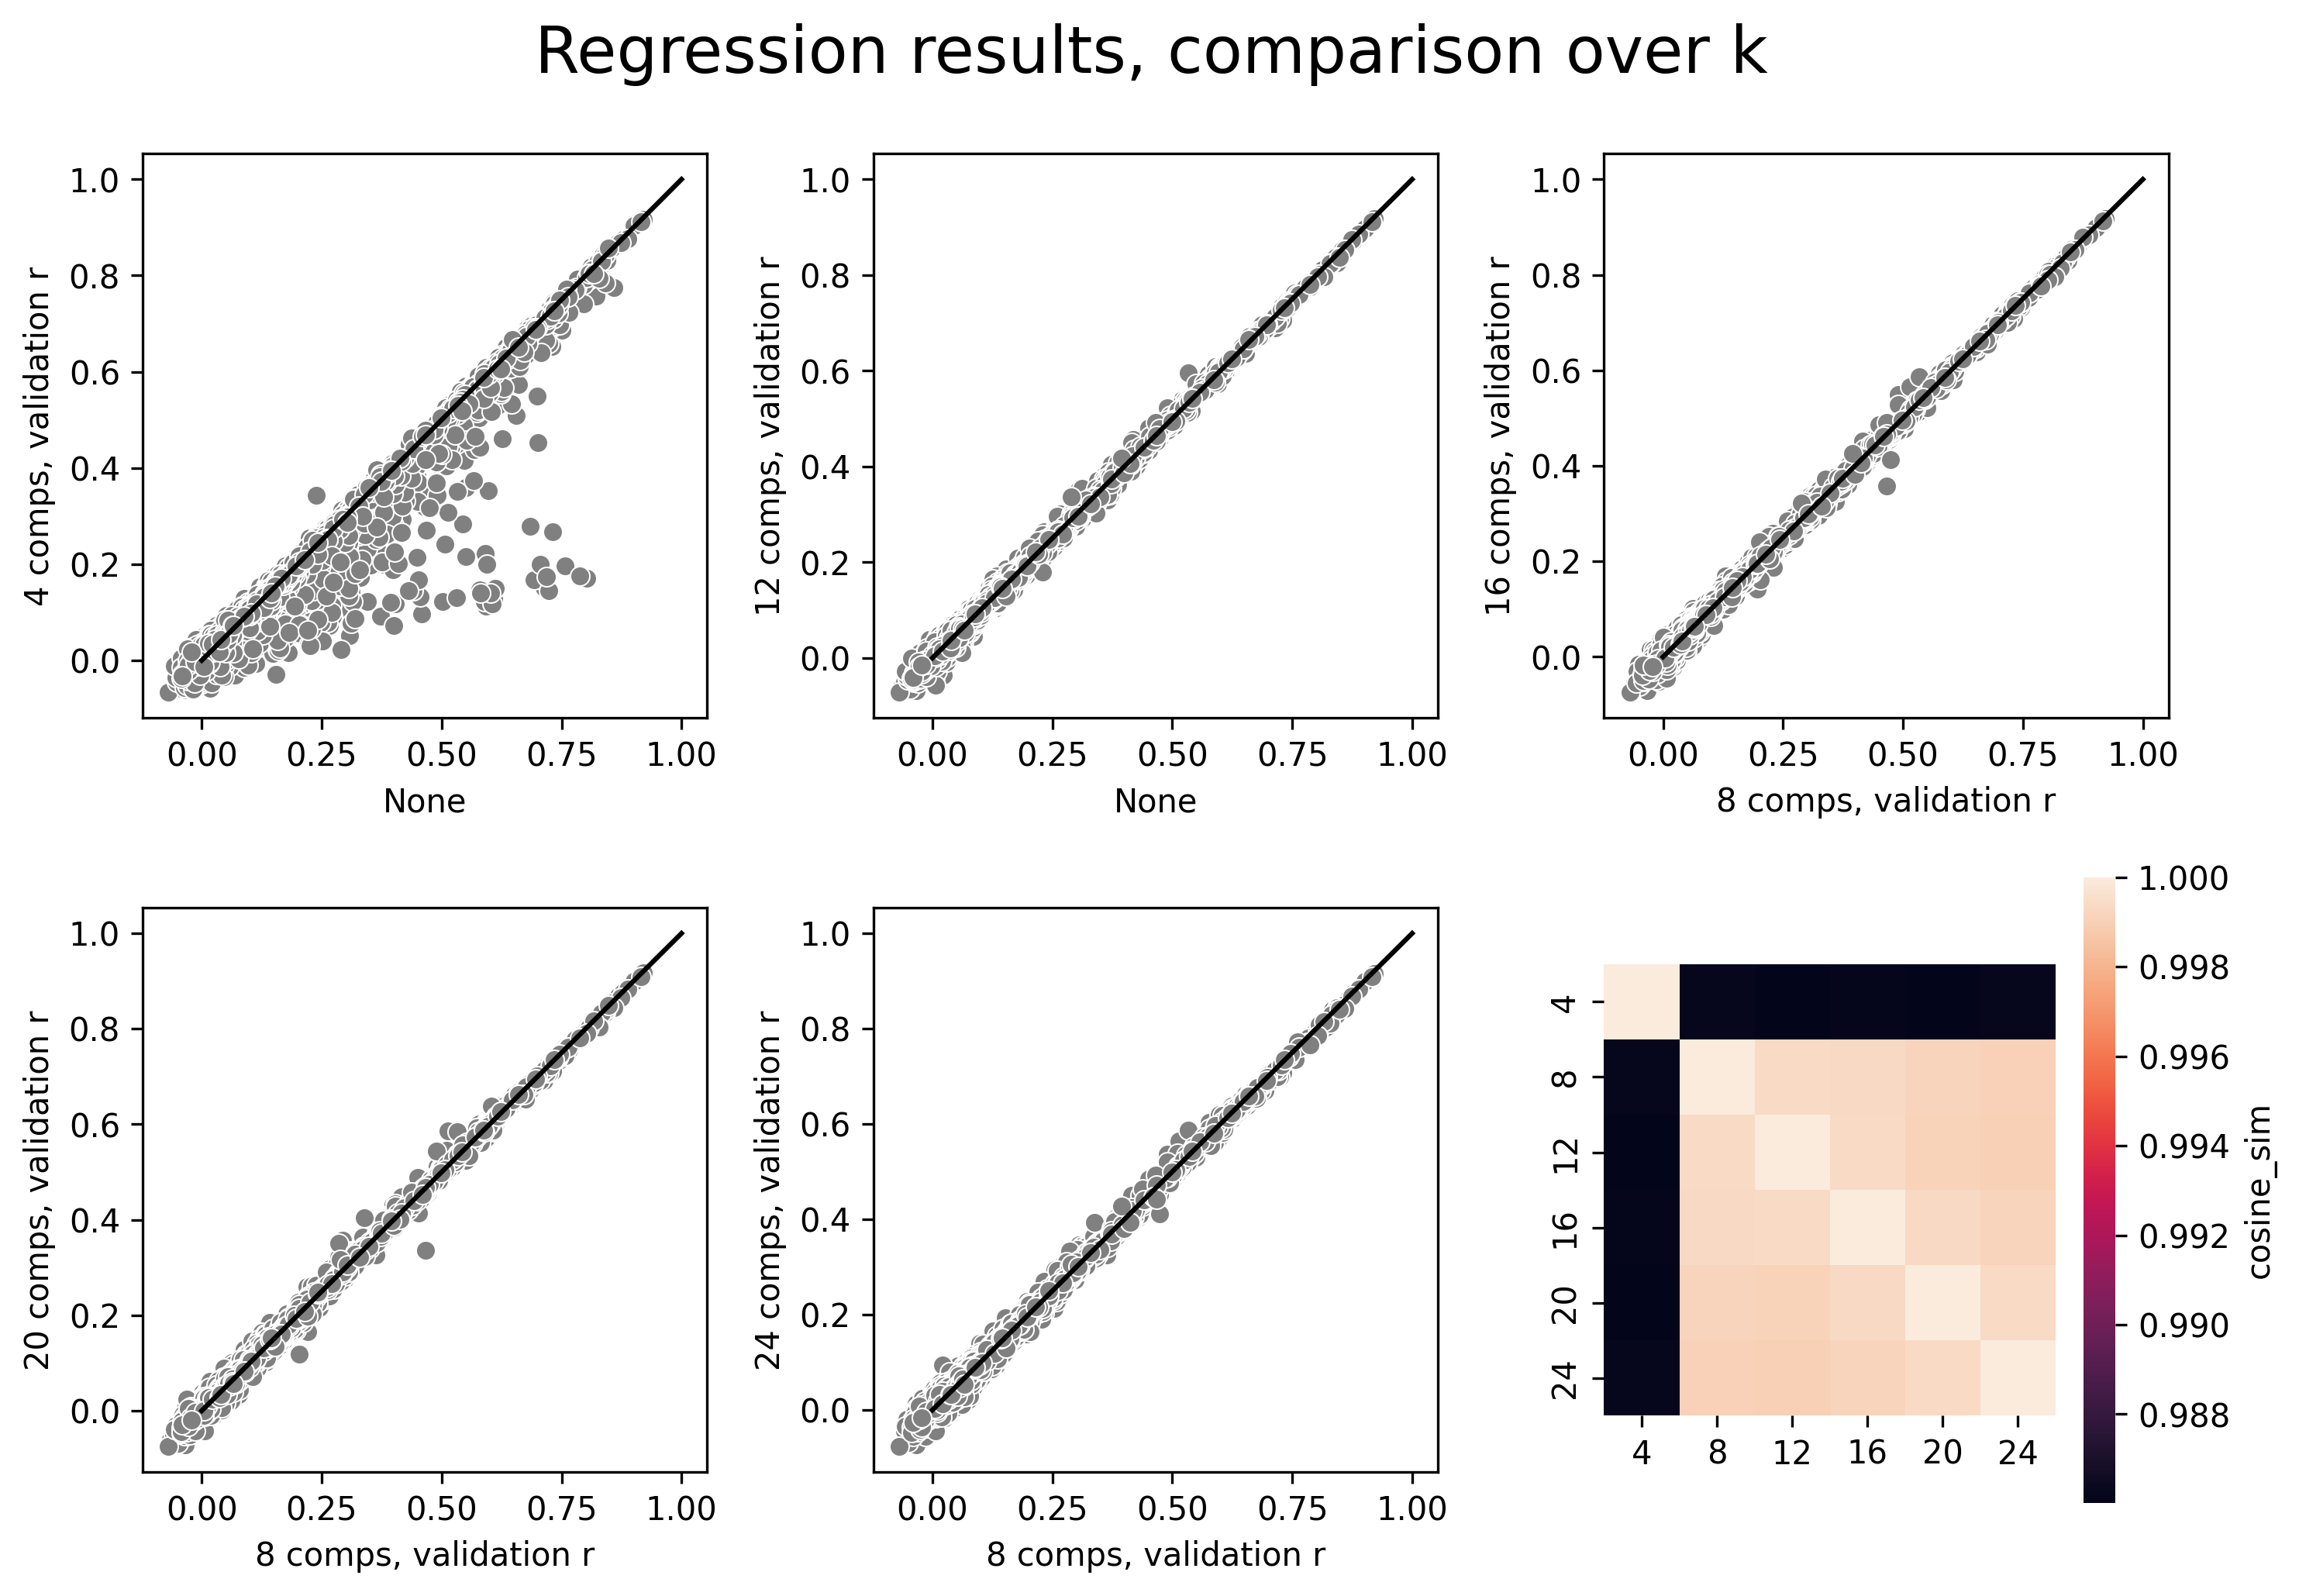

In [8]:
from scipy.stats import wilcoxon, pearsonr
fig, axes = plt.subplots(2,3,dpi = 300, figsize = (10,7), sharey = False, sharex = False)
j = 0
for k in [4, 12, 16, 20, 24]:
    ax = axes[j //3 , j % 3]
    ax.set_box_aspect(1)
    j+=1
    xx = pd.Series(results_CV[8][1])
    yy = pd.Series(results_CV[k][1])
    inters = xx.index.intersection(yy.index)
    xx = xx.loc[inters]
    yy = yy.loc[inters]
    sns.scatterplot(x = xx, y = yy, 
                    ax = ax, color = 'gray')
    ax.set_ylabel(str(k)+' comps, validation r')
    if j //3:
        ax.set_xlabel('8 comps, validation r')
    p = wilcoxon(x = xx,
         y = yy,
         zero_method='wilcox', 
         correction=False).pvalue
    #pearsonr(xx, yy)
    #ax.text(0.65, 0.95, 'p = '+f"{p:.1e}", fontsize = 7)
    ax.plot([0,1], [0,1], color = 'black')
    #ax.set_title('Init '+str(it))
ax = axes[1,2]
ax.set_box_aspect(1)
k_range = [4, 8, 12, 16, 20, 24]
from sklearn.metrics.pairwise import cosine_similarity
df = pd.DataFrame([results_CV[k][1] for k in k_range],
            index = k_range)
#df.corr()
similarity_matrix = cosine_similarity(df.values)

# Convert the resulting NumPy array back to a pandas DataFrame for better readability
corrs = pd.DataFrame(similarity_matrix, index=df.index, columns=df.index)
sns.heatmap(corrs, cbar_kws = {'label':'cosine_sim'})
plt.suptitle('Regression results, comparison over k', fontsize = 20)
plt.tight_layout()
fig.savefig('figures/regression_comparison_over_k.png', dpi = 400)

## Compare to other methods

In [9]:
test_atac= sc.read_h5ad('data/PBMC/test_atac.h5ad')

In [10]:
babel_pred = anndata.read('scores/babel/babel_rna_predictions_from_atac.pbmc.h5ad')

In [11]:
rna = anndata.read('data/PBMC/pbmc_processed.h5ad')
rna_rel = rna[babel_pred.obs.index,:]
rna_corr_to_babel = rna[babel_pred.obs.index,:]
babel_log = pd.DataFrame(babel_pred.layers['log output'], columns = babel_pred.var.index,
                         index = babel_pred.obs.index)
common_genes = rna_corr_to_babel.var_names.intersection(babel_log.columns)
rna_corr_to_babel = rna_corr_to_babel[:, common_genes]
babel_log = babel_log.loc[:, common_genes]
rna_corr_to_babel = pd.DataFrame(rna_corr_to_babel.layers['log1p'], columns = rna_corr_to_babel .var.index,
                         index = rna_corr_to_babel.obs.index)
babel_pearson = babel_log.corrwith(rna_corr_to_babel)

In [12]:
archr_scores = pd.read_csv('scores/archr/pbmc_all_gene_scores.default', index_col = [0])

In [13]:
testc = ['-'.join(x.split('-')[1:]) for x in test_atac.obs.index]#pd.Index(np.ravel(pd.read_csv('../grouping_results/PBMC/test_cells.csv', index_col = [0]).values))
rna_to_predict = pd.DataFrame(rna[testc,:].layers['log1p'],
                              index = testc,
                              columns = rna.var_names)

In [14]:
archr_scores.columns = [x.split('#')[1] for x in archr_scores.columns]

In [15]:
rel_genes = archr_scores.index.intersection(rna_to_predict.columns)

In [16]:
archr_scores= archr_scores.T.loc[testc,:].loc[:,rel_genes]

In [17]:
archr_pearson = np.log1p(archr_scores).corrwith(rna_to_predict.loc[:,rel_genes])

In [18]:
from scipy.stats import wilcoxon

WilcoxonResult(statistic=3611468.0, pvalue=0.0)
WilcoxonResult(statistic=4530274.0, pvalue=0.0)
WilcoxonResult(statistic=18182088.0, pvalue=0.0)


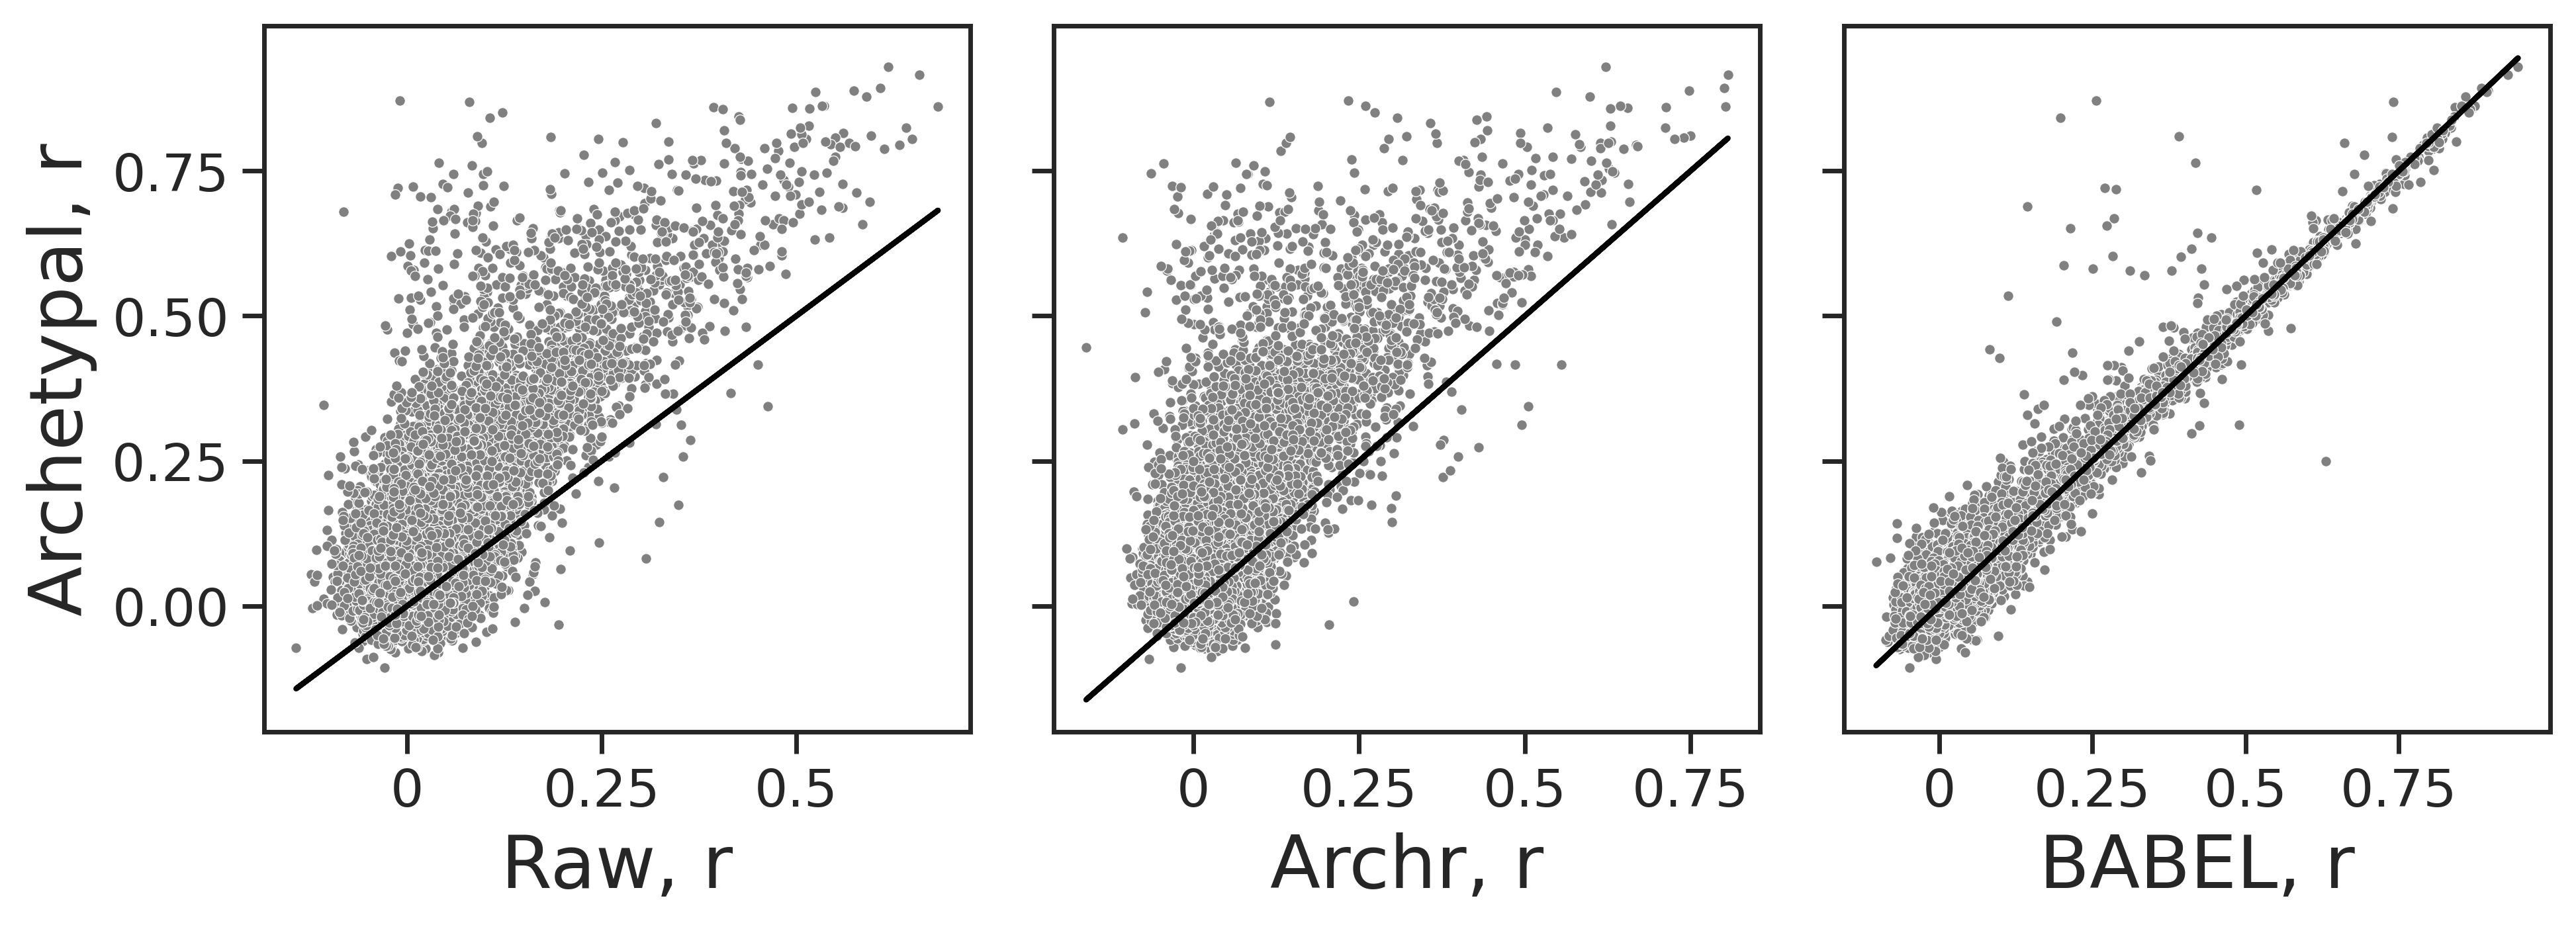

In [19]:
sns.set(font_scale = 1.3, style = 'ticks')
plt.subplots(1,3,figsize = (10,4), dpi = 400, sharey = True)
num_comps = 8
ax = plt.subplot(1,3,1)
ax.set_box_aspect(1)
our_res = pd.Series(results_CV[8][2]).dropna()
raw_pred = pd.Series(results_raw[2]).dropna()

inters = our_res.index.intersection(raw_pred.dropna().index)
xx = raw_pred.loc[inters]
yy = our_res.loc[inters]
#xx = xx.values
#ax.scatter(yy,xx, s = 1, color = 'slategrey')
sns.scatterplot(x = xx, 
            y = yy,
           ax = ax, s = 8, color = 'gray')
ax.plot(xx, xx, color = 'black')
ax.set_xlabel('Raw, r', fontsize = 20)
ax.set_ylabel('Archetypal, r', fontsize = 20)
ax.set_xticks([0, 0.25, 0.5], [0, 0.25, 0.5])
print(wilcoxon(x = yy,
         y = xx))

ax = plt.subplot(1,3,2)
ax.set_box_aspect(1)
inters = our_res.index.intersection(archr_pearson.dropna().index)
xx = archr_pearson.loc[inters]
yy = our_res.loc[inters]
#xx = xx.values
sns.scatterplot(x = xx, 
            y = yy,
           ax = ax, s = 8, color = 'gray')
ax.plot(xx, xx, color = 'black')
ax.set_xlabel('Archr, r', fontsize = 20)
ax.set_xticks([0, 0.25, 0.5, 0.75], [0, 0.25, 0.5, 0.75])
print(wilcoxon(x = yy, 
         y = xx))

ax = plt.subplot(1,3,3)
ax.set_box_aspect(1)
#j+=1
inters = our_res.index.intersection(babel_pearson.dropna().index)
xx = babel_pearson.loc[inters]
yy = our_res.loc[inters]
#xx = xx.values
sns.scatterplot(x = xx, 
            y = yy,
           ax = ax, s = 8, color = 'gray')
ax.plot(xx, xx, color = 'black')
ax.set_xlabel('BABEL, r', fontsize = 20)
ax.set_xticks([0, 0.25, 0.5, 0.75], [0, 0.25, 0.5, 0.75])
    #ax.set_title(str(num_comps)+' components')
plt.tight_layout()
print(wilcoxon(x = np.array(yy), 
         y = np.array(xx)))
plt.savefig('figures/arch_vs_all_CV_new_folds.png', dpi = 800)
plt.savefig('figures/arch_vs_all_CV_new_folds.svg', dpi = 800)